In [17]:
from fdip import FDIP
from matplotlib.colors import ListedColormap

In [2]:
p = FDIP("slagheap_corr")
print(p)

18/08/26 - 07:43:55 - pyGIMLi - INFO - filtering: nd=696, nf=9
18/08/26 - 07:43:55 - pyGIMLi - INFO - Sum(ind): 696
18/08/26 - 07:43:55 - pyGIMLi - INFO - filtered: nd=696, nf=9


SIP data: nf=9 nc=0 nv=59 Data: Sensors: 40 data: 696, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


In [3]:
p.loadResults(loadFit=True)

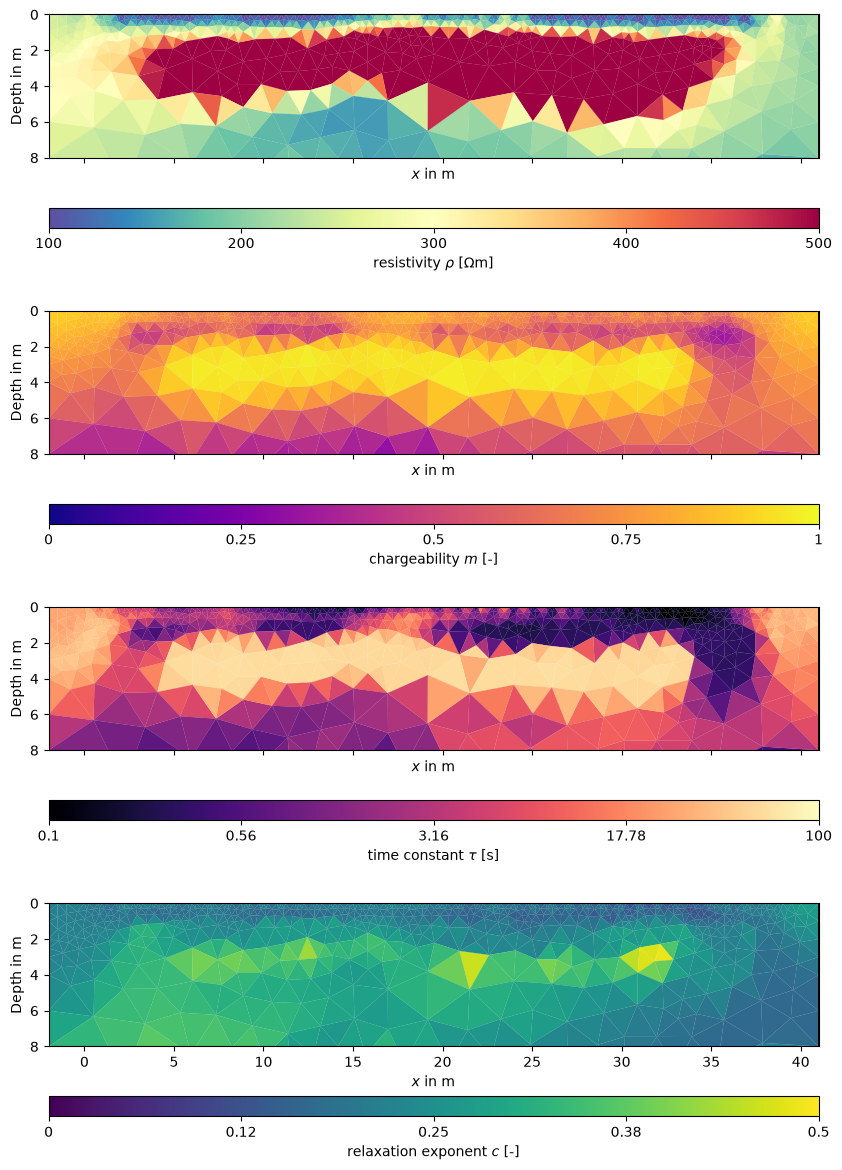

In [9]:
ax = p.showColeColeParameters(rlim=(100, 500), mlim=(0, 1), tlim=(0.1, 100),
                         coverage=1)
for a in ax: a.set_ylim(-8, 0)

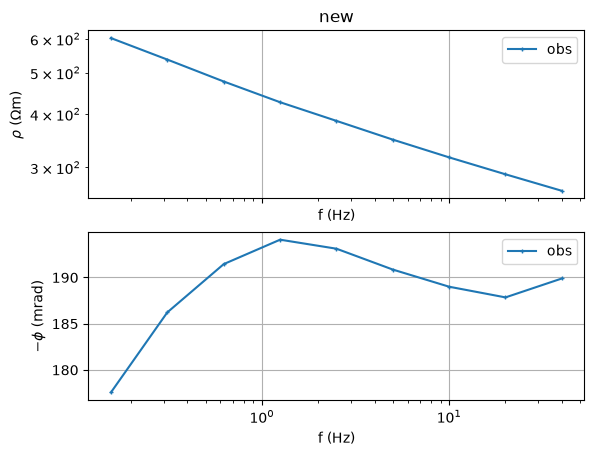

In [10]:
spec = p.getModelSpectrum([23, -2.5])
spec.showData();

[0 1 2]
[3 4 5]
[6 7 8]


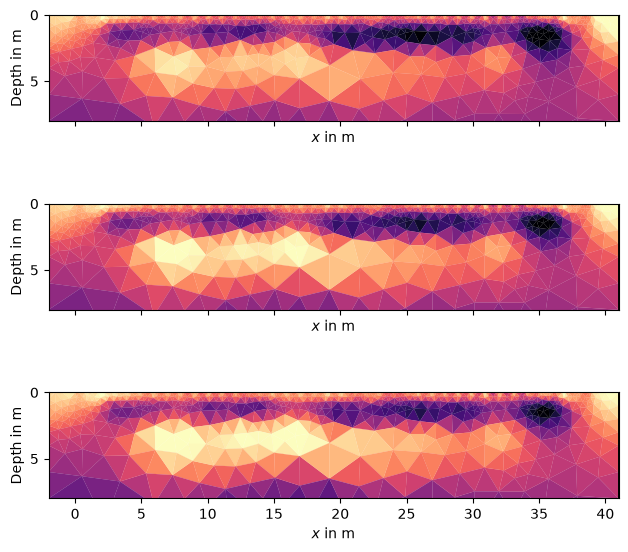

In [13]:
import numpy as np
import matplotlib.pyplot as plt
res = np.median(p.RES, axis=1)
fi = np.nonzero(p.freq < 1.0)[0]
print(fi)
sLow = np.mean(np.sin(p.PHI[:, fi]) / p.RES[:, fi], axis=1)
fi = np.nonzero((p.freq >= 1.0)&(p.freq < 10.0))[0]
print(fi)
sMid = np.mean(np.sin(p.PHI[:, fi]) / p.RES[:, fi], axis=1)
fi = np.nonzero(p.freq >= 10.0)[0]
print(fi)
sHigh = np.mean(np.sin(p.PHI[:, fi]) / p.RES[:, fi], axis=1)
fig, ax = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(6, 6))
kw = dict(cMin=0.1, cMax=3, logScale=True, cMap="magma", colorBar=False)
p.pd.show(sLow*1e3, ax=ax[0], **kw)
p.pd.show(sMid*1e3, ax=ax[1], **kw)
p.pd.show(sHigh*1e3, ax=ax[2], **kw)
for a in ax: a.set_ylim(-8, 0)

[0.156 0.312 0.625]
[1.25 2.5  5.  ]
[10. 20. 40.]


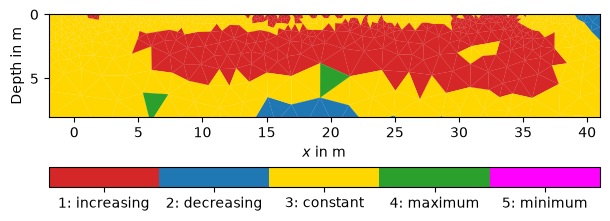

In [33]:
fdip = p
frange = [0.1, 1.0, 7.0, 100.0]
nfr = len(frange)-1
fres = np.zeros((len(fdip.res), nfr))
fphi = np.zeros((len(fdip.res), nfr))
for i in range(nfr):
    find = (fdip.freq > frange[i]) & (fdip.freq <= frange[i+1])
    print(fdip.freq[find])
    fres[:, i] = np.mean(fdip.RES[:, find], axis=1)
    fphi[:, i] = np.mean(fdip.PHI[:, find], axis=1)

fs2s = 1. / fres * np.sin(fphi)
means = np.mean(fs2s, axis=1)
der1 = (fs2s[:, 1] - fs2s[:, 0]) / (fs2s[:, 1] + fs2s[:, 0]) * 2  #means
der2 = (fs2s[:, 2] - fs2s[:, 1]) / (fs2s[:, 2] + fs2s[:, 1]) * 2  # means
typ = np.zeros(len(fdip.res))
typ[(der1 > 0) & (der2 > 0)] = 1  # ascending
typ[(der1 < 0) & (der2 < 0)] = 2  # descending
typ[(der1 > 0) & (der2 < 0)] = 4  # up and down (min-max-min)
typ[(der1 < 0) & (der2 > 0)] = 5  # down and up (max-min-max)
typ[np.sqrt(np.abs(der1*der2)) < 0.1] = 3  # constant (<10%)
# typ = np.sign(der1 * der2) * (np.abs(np.sign(der1) - np.sign(der2)) + 1)
co = 1 # (means > 1e-5) & (fdip.coverage > -0.25)  # 0.1mS/m
cm = ListedColormap(["tab:red", "tab:blue", "gold", "tab:green", "magenta"])
labels = np.array(["1: increasing", "2: decreasing", "3: constant",
                   "4: maximum", "5: minimum"])
ax, cb = fdip.pd.show(typ, coverage=co, cMin=.50, cMax=5.5, cMap=cm,
                      xlabel="x [m]", ylabel="z [m]", showBoundary=False)
ax.set_ylim(-8, 0)
cb.set_ticks([1, 2, 3, 4, 5])
cb.set_ticklabels(labels);

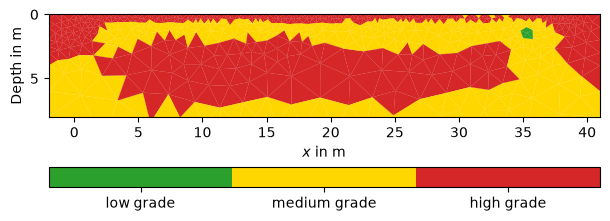

In [ ]:
fs2sMF = fs2s[:, 1] * 1000
grade = (fs2sMF > 0.1) + 1.0
grade[fs2sMF > .7] = 3
cm = ListedColormap(["tab:green", "gold", "tab:red"])
ax, cb = fdip.pd.show(grade, cMin=.5, cMax=3.5, cMap=cm,
                      xlabel="x [m]", ylabel="z [m]", showBoundary=False)
ax.set_ylim(-8, 0)
cb.set_ticks([1, 2, 3])
cb.set_ticklabels(["low grade", "medium grade", "high grade"])